Clustering

In [79]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data
y = data.target
print(X[:6,:])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]]


In [80]:
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

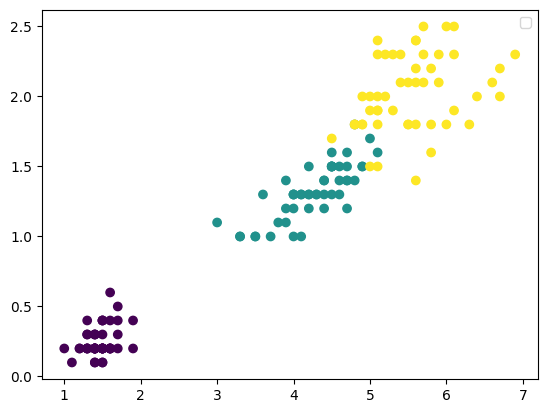

In [81]:
import matplotlib.pyplot as plt
plt.scatter(X[:,2],X[:,3],c =y)
plt.legend()
plt.show()

K Means Clustering

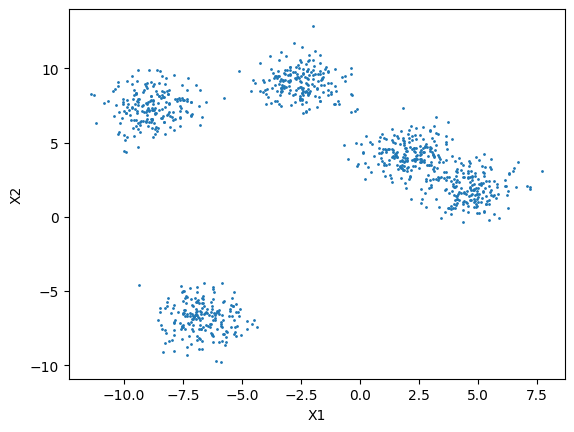

In [82]:
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=1000,centers =5 ,random_state = 42)
plt.scatter(X[:,0],X[:,1],s = 1)
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

In [83]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 5)
y_pred = kmeans.fit_predict(X)

In [84]:
kmeans.cluster_centers_

array([[-8.80798056,  7.40425704],
       [ 2.03639615,  4.26762858],
       [-6.68630691, -6.81139455],
       [-2.50265159,  9.03963769],
       [ 4.66534309,  1.87476184]])

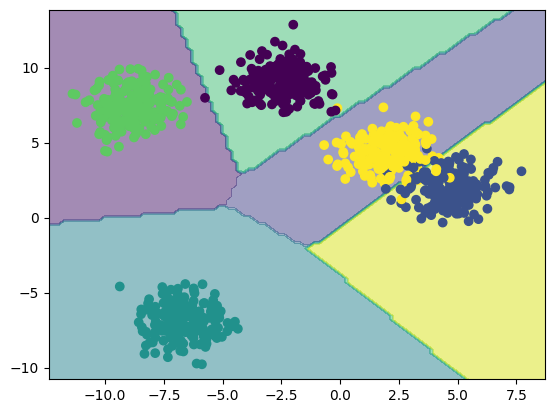

In [85]:
import numpy as np

X0_min , X0_max = X[:,0].min() - 1 , X[:,0].max() + 1
X1_min , X1_max = X[:,1].min() - 1 , X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(X0_min,X0_max,100),
    np.linspace(X1_min,X1_max,100)
)

X_new = np.c_[xx.ravel(),yy.ravel()]
y_pred = kmeans.predict(X_new)

y_pred = y_pred.reshape(xx.shape)

plt.contourf(xx,yy,y_pred,alpha = 0.5)
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

Centroid Initialization Methods

If you happen to know approximately where the centroids should be (e.g., if you ran
another clustering algorithm earlier), then you can set the init hyperparameter to a
NumPy array containing the list of centroids, and set n_init to 1:


good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])<br><br>
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1)


Mini-Batch K-Means

In [86]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters = 5)
minibatch_kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism `on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",'auto'


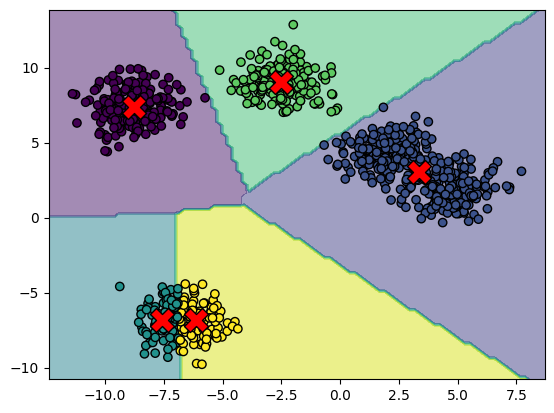

In [87]:
import numpy as np

X0_min , X0_max = X[:,0].min() - 1 , X[:,0].max() + 1
X1_min , X1_max = X[:,1].min() - 1 , X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(X0_min,X0_max,100),
    np.linspace(X1_min,X1_max,100)
)

X_new = np.c_[xx.ravel(),yy.ravel()]
y_pred = minibatch_kmeans.predict(X_new)

y_pred = y_pred.reshape(xx.shape)
labels = minibatch_kmeans.labels_

plt.contourf(xx,yy,y_pred,alpha = 0.5 , cmap ='viridis')
plt.scatter(X[:,0],X[:,1],c=labels, edgecolor = 'black', cmap = 'viridis')
plt.scatter(minibatch_kmeans.cluster_centers_[:,0],
            minibatch_kmeans.cluster_centers_[:,1],
            s = 300, c= 'red', marker = "X", edgecolor = 'black')
plt.show()

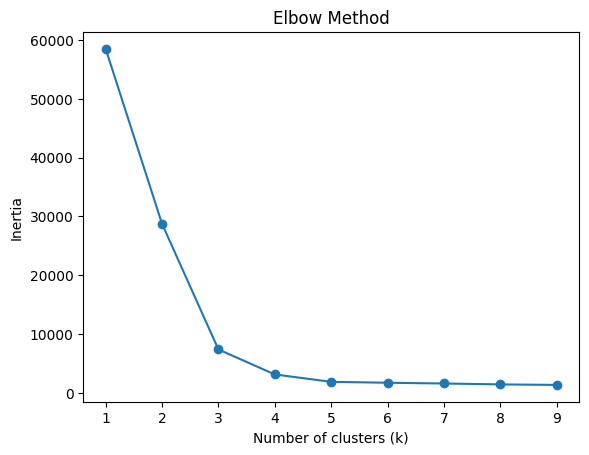

In [88]:
inertias = []
k_values = range(1,10)

for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state =42)
    kmeans.fit_transform(X)
    inertias.append(kmeans.inertia_)

plt.plot(k_values,inertias, marker = 'o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

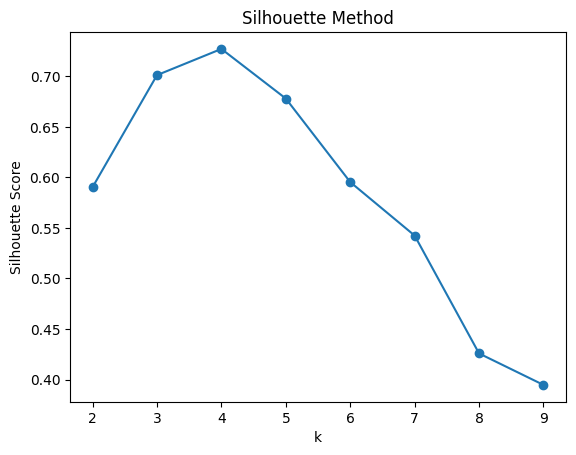

In [89]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

scores = []
k_values = range(2, 10) 

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.plot(k_values, scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

s = (b-a)/max(a,b)<br><br> a = distance to same cluster <br> b = distance to nearest other cluster


Using KMeans for Image segmentation

In [90]:
from matplotlib.image import imread
image = imread("image.jpg")
image.shape

(1748, 3840, 3)

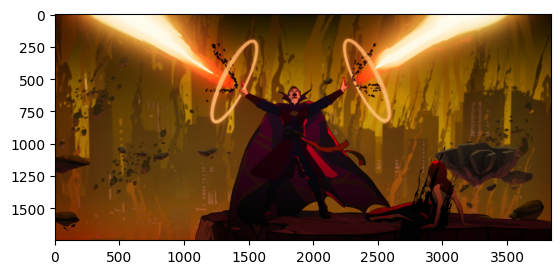

In [91]:
plt.imshow(image)

In [92]:
X= image.reshape( -1,3)
kmeans = KMeans(n_clusters = 4).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img =  segmented_img.reshape(image.shape)

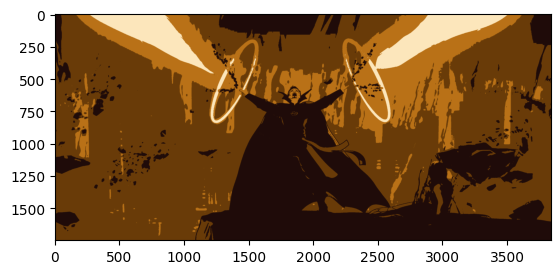

In [93]:
segmented_img = segmented_img / 255.0
plt.imshow(segmented_img)

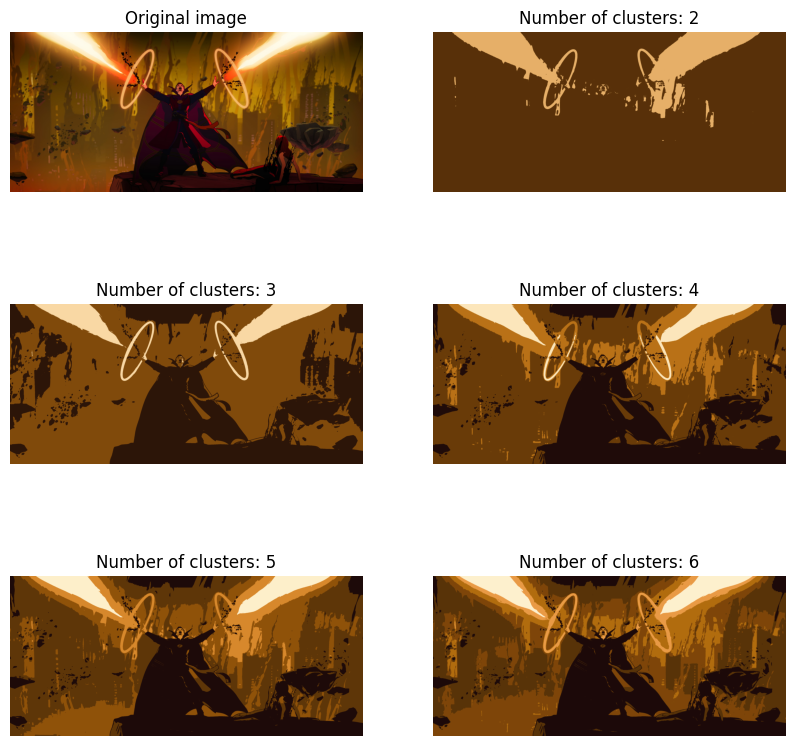

In [94]:

plt.figure(figsize =(10,10))
plt.subplot(3,2,1)
plt.imshow(image)
plt.axis('off')
plt.title("Original image")

X = image.reshape(-1,3)

for i in range(2,7):
    kmeans = KMeans(n_clusters = i).fit(X)
    segmented_image = kmeans.cluster_centers_[kmeans.labels_]
    segmented_image = (segmented_image.reshape(image.shape))/[255.0]

    plt.subplot(3,2,i)
    plt.imshow(segmented_image)
    plt.axis("off")
    plt.title(f"Number of clusters: {i}")

Using Cluster for Preprocessing

In [95]:
from sklearn.datasets import load_digits
X_digits,y_digits = load_digits(return_X_y= True)

In [96]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_digits,y_digits)

In [97]:
import warnings
warnings.filterwarnings('ignore')

In [98]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state = 42)
log_reg.fit(X_train,y_train)
log_reg.score(X_test,y_test)

0.9533333333333334

In [99]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ("kmeans",KMeans(n_clusters = 50)),
    ("log",LogisticRegression())
])
pipeline.fit(X_train,y_train)
pipeline.score(X_test,y_test)

0.9666666666666667

In [100]:
from sklearn.model_selection import GridSearchCV
param_grid = dict(kmeans__n_clusters = range(2,100))
grid_clf = GridSearchCV(pipeline,param_grid,cv=3,verbose=2)
grid_clf.fit(X_train,y_train)
print(grid_clf.best_params_)

Fitting 3 folds for each of 98 candidates, totalling 294 fits
[CV] END ...............................kmeans__n_clusters=2; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=2; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=2; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=4; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=4; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=4; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=5; total time=   0.0s
[CV] END ...............................kmeans__n_clusters=5; total time=   0.0s
[CV] END ...............................kmeans_

Using Clusterin for Semi Supervised Learning

In [101]:
n_labeled =50
log_reg =LogisticRegression()
log_reg.fit(X_train[:n_labeled],y_train[:n_labeled])

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [102]:
log_reg.score(X_test,y_test)

0.8555555555555555

In [103]:
k = 50
kmeans =KMeans(n_clusters=k)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist,axis=0)
X_representative_digits = X_train[representative_digit_idx]

DBSCAN<br>Identifing cluster of arbitary shapes

In [127]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
X,y = make_moons(n_samples = 1000,noise=.05)
dbscan = DBSCAN(eps = 0.2, min_samples=5)
dbscan.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.2
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [128]:
dbscan.labels_

array([0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,

In [129]:
len(dbscan.core_sample_indices_)

1000

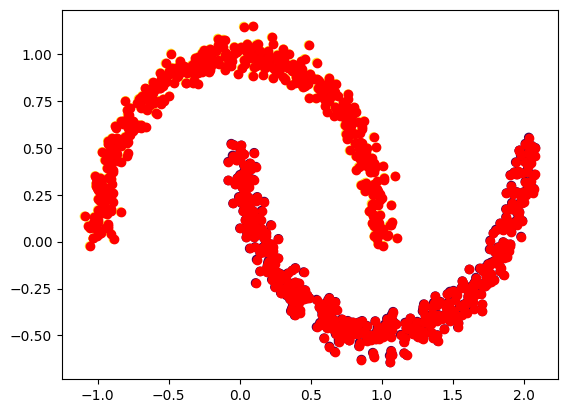

In [130]:
plt.scatter(X[:,0],X[:,1],c=dbscan.labels_)
plt.scatter(X[dbscan.core_sample_indices_,0],
        X[dbscan.core_sample_indices_,1], c ="red")

In [126]:
dbscan.labels_

array([ 0,  1,  0,  2,  0,  1,  0,  3,  4,  5,  0,  6,  2,  0,  5,  3,  2,
        4,  7,  0,  0,  7,  5,  6,  5,  0,  0,  5,  4,  1,  5,  0,  0,  1,
        2,  0, -1,  0,  0,  0,  0,  0,  2,  0,  5, 11, -1,  0, -1,  0,  4,
        1,  3,  0,  7,  0,  0, -1,  2,  2,  0,  2,  0,  0,  0,  3,  4,  5,
        2,  3,  8,  5,  6,  0,  4,  1,  0,  0,  4,  5,  0,  4,  2,  4,  7,
        0,  0,  7,  1,  5,  5,  5,  8,  3,  2, -1, -1,  2,  0, -1,  1,  2,
        2,  0,  5, -1, -1,  4,  0,  7,  6,  2,  2,  7,  0,  2,  0,  1,  6,
        5,  1,  2,  2,  0,  1,  9,  0,  7,  6,  1,  0,  2,  0, -1,  0,  4,
        5,  0,  7,  0,  6,  2,  4,  0,  0,  2,  5,  0, -1,  0,  4,  0,  7,
        1,  0,  0,  0,  4,  7,  0,  0,  0,  0,  1,  1,  4, -1,  0, -1, 10,
       -1,  0,  1,  5,  9,  0,  0,  4,  0,  7,  0,  5,  0,  0,  0,  0, -1,
        1,  2,  7,  8,  4,  5,  3,  1, -1,  2,  0,  0,  5, 10,  0,  5,  3,
        0, 10,  4,  6,  0,  0,  0,  5,  4,  0,  2,  1,  7,  0,  0,  4,  2,
        0,  0,  1,  7,  4